In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("seaborn-v0_8-whitegrid")
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [40]:
epsilons = np.array([1.0, 0.995, 0.99, 0.98, 0.97, 0.96, 0.95, 0.94, 0.93, 0.92, 0.91, 0.9, 0.875, 0.85, 0.825, 0.8, 0.75, 0.5, 0.25, 0.0])
stage_labels = [fr"Stage {stage} ($\epsilon={round(epsilons[stage-1], 3)})$" for stage in range(1, 21)]

In [41]:
data02 = pd.read_csv("0_to_02/results/robust_evaluation.csv")
data05 = pd.read_csv("0_to_05/results/robust_evaluation.csv")
data10 = pd.read_csv("0_to_10/results/robust_evaluation.csv")

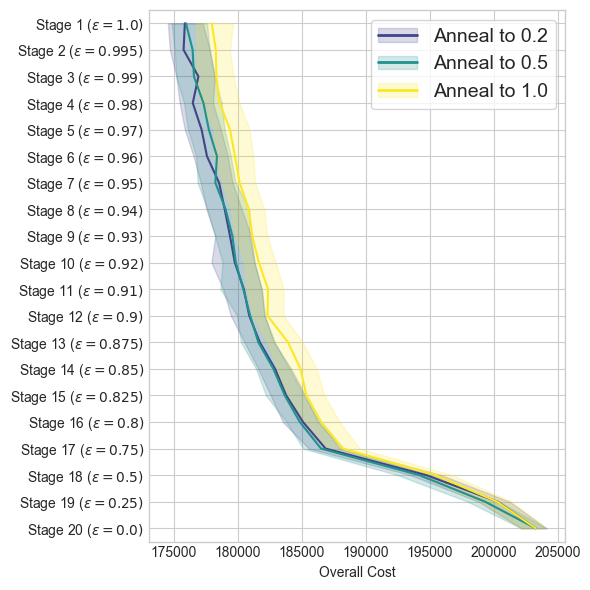

In [48]:
fig, ax = plt.subplots(1, figsize=(6, 6))
cmap = plt.cm.viridis
colours = {0.2: cmap(0.2), 0.5: cmap(0.5), 1.0: cmap(1.0)}

ax.plot(data02.median(), range(20), c=colours[0.2])
ax.fill_betweenx(range(20), data02.quantile(0.25), data02.quantile(0.75), alpha=0.2, color=colours[0.2])

ax.plot(data05.median(), range(20), c=colours[0.5])
ax.fill_betweenx(range(20), data05.quantile(0.25), data05.quantile(0.75), alpha=0.2, color=colours[0.5])

ax.plot(data10.median(), range(20), c=colours[1.0])
ax.fill_betweenx(range(20), data10.quantile(0.25), data10.quantile(0.75), alpha=0.2, color=colours[1.0])

legend_handles = [
    (mpatches.Patch(facecolor=colours[0.2], edgecolor=colours[0.2], alpha=0.2), Line2D([0], [0], color=colours[0.2], lw=2)),
    (mpatches.Patch(facecolor=colours[0.5], edgecolor=colours[0.5], alpha=0.2), Line2D([0], [0], color=colours[0.5], lw=2)),
    (mpatches.Patch(facecolor=colours[1.0], edgecolor=colours[1.0], alpha=0.2), Line2D([0], [0], color=colours[1.0], lw=2)),
]
legend_labels = [
    "Anneal to 0.2",
    "Anneal to 0.5",
    "Anneal to 1.0"
]

ax.set_yticks(range(20))
ax.set_yticklabels(stage_labels)
ax.set_xlabel("Overall Cost")
ax.set_ylim(-0.5, 19.5)
ax.yaxis.set_inverted(True)
ax.legend(handles=legend_handles, labels=legend_labels, fontsize=14, frameon=True)
plt.tight_layout()
fig.savefig("../../../plt/vary_annealing_robustness.pdf")